# Parte 4 — Experimento B: BERTweet
### Workshop: Clasificación de Emociones en Twitter

**Modelo:** `vinai/bertweet-base`  
**Pre-entrenamiento:** 850M tweets en inglés  
**Tokenizador:** BPE entrenado sobre texto de Twitter

BERTweet tiene la misma arquitectura que BERT-base (12 capas, 768 dimensiones, ~110M parámetros), pero fue pre-entrenado desde cero sobre tweets.

> **Nota sobre `normalization=True`:** el tokenizador normaliza las URLs a `HTTPURL` y los @mentions a `@USER` antes de tokenizar, replicando el preprocesamiento usado durante el pre-entrenamiento.

**Prerequisito:** haber ejecutado `part-1-data.ipynb` y `part-2-pipeline.ipynb`

In [3]:
%run part2_pipeline.ipynb


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
Using the latest cached version of the dataset since tweet_eval couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'emotion' at /teamspace/studios/this_studio/.cache/huggingface/datasets/tweet_eval/emotion/0.0.0/b3a375baf0f409c77e6bc7aa35102b7b3534f8be (last modified on Wed May 27 00:22:14 2026).


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 374
    })
})
compute_metrics OK
make_tokenized_dataset OK
full_evaluation OK
plot_training_curves OK
make_trainer OK

Pipeline lista. Puedes continuar con part-3-distilbert.ipynb


## Configuración del experimento

In [5]:
MODEL_CHECKPOINT = "vinai/bertweet-base"
HF_REPO          = "Obeney/tweeteval-emotion-bertweet"  # <-- cambia esto
LR               = 2e-5

### 📝 TODO 4.1 — Tokenizar el dataset con BERTweet

Importante: carga el tokenizador con `normalization=True`.

In [6]:
tok_bertweet = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, normalization=True)
ds_bertweet  = make_tokenized_dataset(tok_bertweet)
print(ds_bertweet)

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Map:   0%|          | 0/3257 [00:00<?, ? examples/s]

Map:   0%|          | 0/1421 [00:00<?, ? examples/s]

Map:   0%|          | 0/374 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 374
    })
})


### 📝 TODO 4.2 — Cargar el modelo BERTweet

Mismo procedimiento que con DistilBERT pero con `MODEL_CHECKPOINT`. Imprime el número de parámetros y compáralo con DistilBERT.

In [7]:
model_bertweet = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

total     = sum(p.numel() for p in model_bertweet.parameters())
trainable = sum(p.numel() for p in model_bertweet.parameters() if p.requires_grad)
print(f"Parámetros totales:     {total:,}")
print(f"Parámetros entrenables: {trainable:,}")
# Esperado: ~110M total vs ~66M de DistilBERT

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parámetros totales:     134,903,044
Parámetros entrenables: 134,903,044


### 📝 TODO 4.3 — Entrenar y evaluar BERTweet

Repite el mismo proceso del TODO 3.3 con el modelo y dataset de BERTweet.

**Pregunta:** ¿necesitarías cambiar el learning rate para BERTweet vs DistilBERT? ¿Por qué sí o por qué no?

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.873838,0.790606,0.678956,0.745989
2,0.573996,0.648734,0.725745,0.786096
3,0.436427,0.576806,0.750684,0.802139
4,0.354615,0.590409,0.766032,0.815508
5,0.266501,0.580092,0.771381,0.818182


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

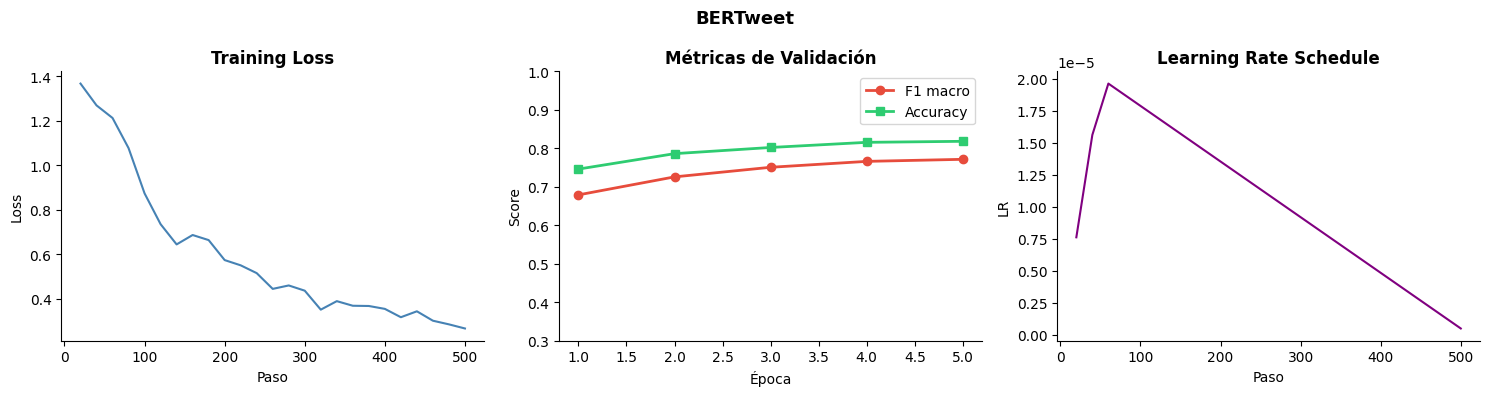

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



  Test — BERTweet
              precision    recall  f1-score   support

       anger     0.8774    0.8978    0.8875       558
         joy     0.8551    0.8408    0.8479       358
    optimism     0.7619    0.6504    0.7018       123
     sadness     0.7964    0.8194    0.8077       382

    accuracy                         0.8410      1421
   macro avg     0.8227    0.8021    0.8112      1421
weighted avg     0.8400    0.8410    0.8400      1421



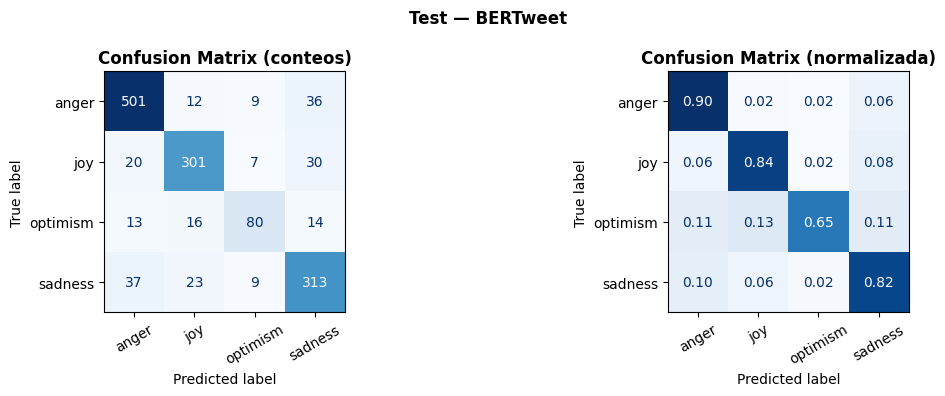

In [8]:
trainer_bertweet = make_trainer(
    model        = model_bertweet,
    tokenizer    = tok_bertweet,
    tokenized_ds = ds_bertweet,
    output_dir   = "./checkpoints/bertweet",
    lr           = LR,
)

trainer_bertweet.train()
plot_training_curves(trainer_bertweet, title="BERTweet")
metrics_bertweet = full_evaluation(
    trainer_bertweet,
    ds_bertweet["test"],
    model_name="BERTweet"
)

Pregunta: ¿necesitarías cambiar el learning rate para BERTweet vs DistilBERT? ¿Por qué sí o por qué no?

No es estrictamente necesario cambiar el learning rate entre DistilBERT y BERTweet, pero puede ser beneficioso ajustarlo. La razón principal es que ambos modelos tienen arquitecturas y tamaños diferentes, así como dominios de pre-entrenamiento distintos, lo que influye en cómo se adaptan durante el fine-tuning

## Push to Hub

In [9]:
model_bertweet.push_to_hub(HF_REPO, commit_message="BERTweet fine-tuning — TweetEval emotion")
tok_bertweet.push_to_hub(HF_REPO)
print(f"Modelo publicado en: https://huggingface.co/{HF_REPO}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Modelo publicado en: https://huggingface.co/Obeney/tweeteval-emotion-bertweet
